Import data


In [13]:
import pandas as pd

file_path = '/content/Team Assignment 1 Data 2026.xlsx'
df = pd.read_excel(file_path)

print("First 5 rows of the dataset:")
display(df.head())

print("\nInformation about the dataset (data types, non-null values):")
df.info()

print("\nDescriptive statistics of the numerical columns:")
display(df.describe(include='all'))

First 5 rows of the dataset:


,Post_ID,Caption_Length,ZCaption_Length,Topic_Prod_Features,Topic_Prod_Features_Positive,Topic_Prod_Features_Negative,Topic_Promo_Deal,Topic_Promo_Deal_Positive,Topic_Promo_Deal_Negative,Topic_Lifestyle_Values,...,Platform,Post_Type,Influencer_Gender,Influencer_Age,Influencer_Tier,Follower_Count_K,Caption_Sentiment,Engagement_Rate,Click_Through,Comment_Count
0,1,26,-0.6817,0,0,0,1,1,0,0,...,0,1,1,24.2,1,669.4,5,7.90,1,42
1,2,29,-0.5492,0,0,0,0,0,0,0,...,1,1,0,26.0,0,44.8,5,9.55,0,48
2,3,25,-0.7258,0,0,0,0,0,0,0,...,1,1,0,18.6,0,45.3,4,10.57,0,95
3,4,17,-1.0792,1,1,0,0,0,0,0,...,1,1,0,23.0,0,45.9,2,9.14,1,28
4,5,40,-0.0632,0,0,0,0,0,0,0,...,0,1,1,31.8,0,19.1,4,6.63,0,10



Information about the dataset (data types, non-null values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Post_ID                          600 non-null    int64  
 1   Caption_Length                   600 non-null    int64  
 2   ZCaption_Length                  600 non-null    float64
 3   Topic_Prod_Features              600 non-null    int64  
 4   Topic_Prod_Features_Positive     600 non-null    int64  
 5   Topic_Prod_Features_Negative     600 non-null    int64  
 6   Topic_Promo_Deal                 600 non-null    int64  
 7   Topic_Promo_Deal_Positive        600 non-null    int64  
 8   Topic_Promo_Deal_Negative        600 non-null    int64  
 9   Topic_Lifestyle_Values           600 non-null    int64  
 10  Topic_Lifestyle_Values_Positive  600 non-null    int64  
 11  Topic_Lifestyle_Values

,Post_ID,Caption_Length,ZCaption_Length,Topic_Prod_Features,Topic_Prod_Features_Positive,Topic_Prod_Features_Negative,Topic_Promo_Deal,Topic_Promo_Deal_Positive,Topic_Promo_Deal_Negative,Topic_Lifestyle_Values,...,Platform,Post_Type,Influencer_Gender,Influencer_Age,Influencer_Tier,Follower_Count_K,Caption_Sentiment,Engagement_Rate,Click_Through,Comment_Count
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,...,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,41.431667,0.000002,0.541667,0.431667,0.066667,0.343333,0.301667,0.013333,0.436667,...,0.496667,0.548333,0.348333,27.061167,0.42000,184.040167,3.705000,7.635767,0.496667,48.710000
std,173.349358,22.656733,1.000832,0.498677,0.495722,0.249652,0.475218,0.459364,0.114793,0.496386,...,0.500406,0.498074,0.476840,4.687682,0.49397,229.175503,1.086251,2.468081,0.500406,44.899694
min,1.000000,8.000000,-1.476800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,18.000000,0.00000,5.000000,1.000000,0.300000,0.000000,2.000000
25%,150.750000,25.000000,-0.725800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,23.800000,0.00000,23.600000,3.000000,6.130000,0.000000,19.000000
50%,300.500000,37.000000,-0.195800,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,27.000000,0.00000,42.450000,4.000000,7.695000,0.000000,35.000000
75%,450.250000,53.000000,0.511000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,30.300000,1.00000,328.550000,5.000000,9.305000,1.000000,64.000000
max,600.000000,199.000000,6.960400,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,42.700000,1.00000,794.100000,5.000000,15.080000,1.000000,278.000000


Data Preparation

In [14]:
# Create dummies for Product_Category
df_dummies = pd.get_dummies(df['Product_Category'], prefix='ProdCat', drop_first=True).astype(int)
df = pd.concat([df, df_dummies], axis=1)

# List of independent variables (using Beauty as reference)
independent_vars = [
    'Caption_Sentiment', 'ZCaption_Length', 'Topic_Prod_Features',
    'Topic_Promo_Deal', 'Topic_Lifestyle_Values', 'Topic_CTA',
    'Platform', 'Post_Type', 'Influencer_Tier', 'Influencer_Gender',
    'Influencer_Age', 'Follower_Count_K', 'ProdCat_1', 'ProdCat_2'
]

Predicting Engagement Rate

In [15]:
import statsmodels.api as sm

# 1. Prepare Data & Dummies
df = pd.read_excel('/content/Team Assignment 1 Data 2026.xlsx')
prod_dummies = pd.get_dummies(df['Product_Category'], prefix='ProdCat', drop_first=True).astype(float)
df = pd.concat([df, prod_dummies], axis=1)

# 2. Define Variables
X = df[['ZCaption_Length', 'Caption_Sentiment', 'Topic_Prod_Features',
        'Topic_Promo_Deal', 'Topic_Lifestyle_Values', 'Topic_CTA',
        'Platform', 'Post_Type', 'Influencer_Gender', 'Influencer_Age',
        'Influencer_Tier', 'Follower_Count_K', 'ProdCat_1', 'ProdCat_2']]
X = sm.add_constant(X)
Y = df['Engagement_Rate']

# 3. Estimate Model
engagement_model = sm.OLS(Y, X.astype(float)).fit()
print(engagement_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Engagement_Rate   R-squared:                       0.687
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     91.65
Date:                Tue, 31 Mar 2026   Prob (F-statistic):          3.20e-137
Time:                        20:47:54   Log-Likelihood:                -1044.6
No. Observations:                 600   AIC:                             2119.
Df Residuals:                     585   BIC:                             2185.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      4

Predicting Click-Through

In [16]:
import numpy as np

# Prepare variables including framing and engagement
indep_vars = [
    'ZCaption_Length', 'Caption_Sentiment', 'Topic_Prod_Features',
    'Topic_Promo_Deal_Positive', 'Topic_Promo_Deal_Negative',
    'Topic_Lifestyle_Values', 'Topic_CTA_Positive', 'Topic_CTA_Negative',
    'Platform', 'Post_Type', 'Influencer_Gender', 'Influencer_Age',
    'Influencer_Tier', 'Follower_Count_K', 'ProdCat_1', 'ProdCat_2',
    'Engagement_Rate'
]

X = sm.add_constant(df[indep_vars])
Y = df['Click_Through']

# Estimate Logistic Model
click_model = sm.Logit(Y, X.astype(float)).fit()

# Report Odds Ratios
print(np.exp(click_model.params))
print(click_model.summary())

Optimization terminated successfully.
         Current function value: 0.641115
         Iterations 5
const                        0.176074
ZCaption_Length              1.106776
Caption_Sentiment            1.112859
Topic_Prod_Features          1.014191
Topic_Promo_Deal_Positive    1.422338
Topic_Promo_Deal_Negative    5.185775
Topic_Lifestyle_Values       0.934859
Topic_CTA_Positive           2.509302
Topic_CTA_Negative           2.276033
Platform                     0.988148
Post_Type                    1.294239
Influencer_Gender            1.158107
Influencer_Age               0.987782
Influencer_Tier              1.890849
Follower_Count_K             0.999159
ProdCat_1                    0.921712
ProdCat_2                    1.286180
Engagement_Rate              1.099760
dtype: float64
                           Logit Regression Results                           
Dep. Variable:          Click_Through   No. Observations:                  600
Model:                          Logit   D

  Predicting Comment Count

In [17]:
# Prepare variables for the Count Model
X = df[['ZCaption_Length', 'Caption_Sentiment', 'Topic_Prod_Features',
        'Topic_Promo_Deal', 'Topic_Lifestyle_Values', 'Topic_CTA',
        'Platform', 'Post_Type', 'Influencer_Gender', 'Influencer_Age',
        'Influencer_Tier', 'Follower_Count_K', 'ProdCat_1', 'ProdCat_2']]
X = sm.add_constant(X)
Y = df['Comment_Count']

# Estimate Negative Binomial Model (GLM)
comment_model = sm.GLM(Y, X.astype(float),
                       family=sm.families.NegativeBinomial()).fit()

print(comment_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          Comment_Count   No. Observations:                  600
Model:                            GLM   Df Residuals:                      585
Model Family:        NegativeBinomial   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2796.5
Date:                Tue, 31 Mar 2026   Deviance:                       136.84
Time:                        20:47:54   Pearson chi2:                     145.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.3752
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Interaction Effects  (Applied to One Model of Your Choice)

In [18]:
import pandas as pd
import statsmodels.api as sm

# Load and Prep
df = pd.read_excel('/content/Team Assignment 1 Data 2026.xlsx')

# Create dummies for Product_Category (as done in Q1)
prod_dummies = pd.get_dummies(df['Product_Category'], prefix='ProdCat', drop_first=True).astype(float)
df = pd.concat([df, prod_dummies], axis=1)

# Create Interaction Terms
df['CTA_x_Platform'] = df['Topic_CTA'] * df['Platform']
df['Video_x_Sentiment'] = df['Post_Type'] * df['Caption_Sentiment']

# Define the Model with Interactions
# We include the main effects (CTA, Platform, Post_Type, Sentiment) PLUS the interaction terms
indep_vars_interact = [
    'ZCaption_Length', 'Caption_Sentiment', 'Topic_Prod_Features',
    'Topic_Promo_Deal', 'Topic_Lifestyle_Values', 'Topic_CTA',
    'Platform', 'Post_Type', 'Influencer_Tier', 'ProdCat_1', 'ProdCat_2',
    'CTA_x_Platform', 'Video_x_Sentiment'
]

X_interact = sm.add_constant(df[indep_vars_interact].astype(float))
Y = df['Engagement_Rate']

model_interact = sm.OLS(Y, X_interact).fit()

# Compare Adj. R-squared
# (Assuming model1 is your main-effects-only model from Q1)
# Note: model1 is not defined in this cell. You would need to ensure engagement_model is available
# or re-run the main effects model here if you want to compare.
# For now, I will comment this line out to avoid a NameError until model1 is available.
# print(f"Main Effects Adj. R2: {model1.rsquared_adj:.4f}")
print(f"Interaction Model Adj. R2: {model_interact.rsquared_adj:.4f}")
print(model_interact.summary().tables[1])

Interaction Model Adj. R2: 0.6652
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      4.9150      0.337     14.587      0.000       4.253       5.577
ZCaption_Length           -0.5935      0.059    -10.109      0.000      -0.709      -0.478
Caption_Sentiment          0.1240      0.079      1.578      0.115      -0.030       0.278
Topic_Prod_Features        0.0458      0.118      0.388      0.698      -0.186       0.278
Topic_Promo_Deal           0.6376      0.124      5.133      0.000       0.394       0.882
Topic_Lifestyle_Values     0.7408      0.119      6.234      0.000       0.507       0.974
Topic_CTA                  1.0259      0.167      6.135      0.000       0.697       1.354
Platform                   2.3701      0.181     13.062      0.000       2.014       2.726
Post_Type                  1.9087      0.419      4.551 

Generating charts for data exploration...


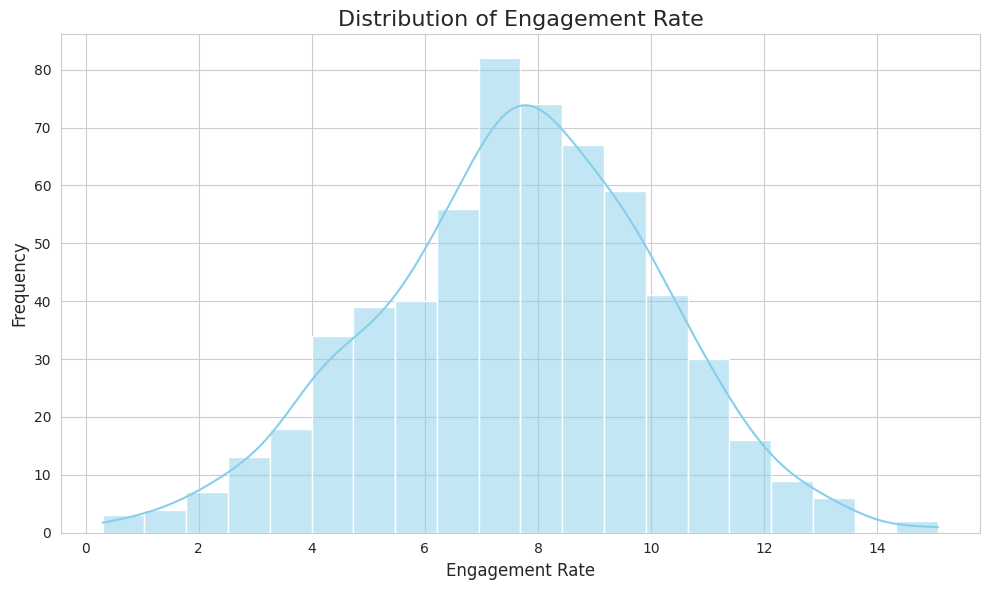

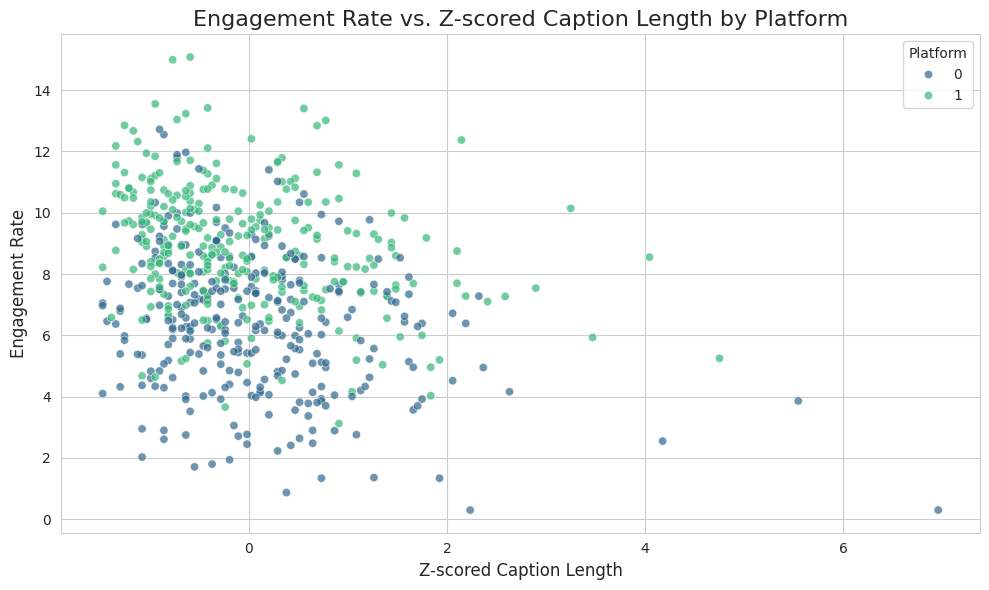

/tmp/ipykernel_12685/4119221738.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Platform', y='Engagement_Rate', data=df, palette='magma')


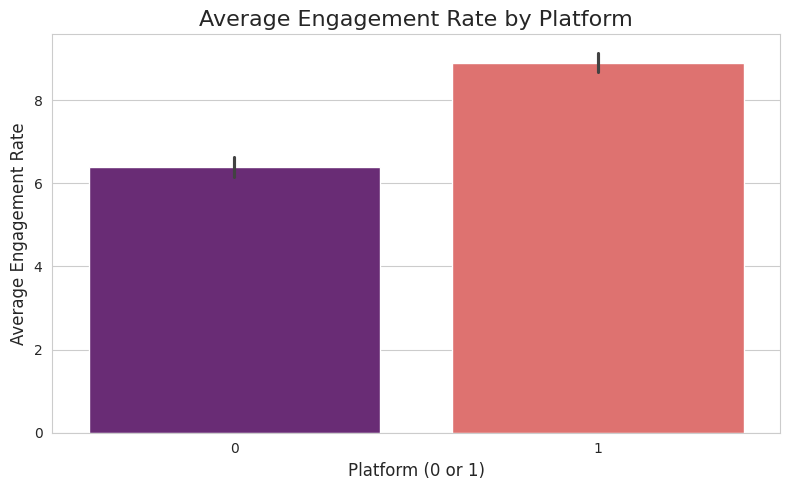

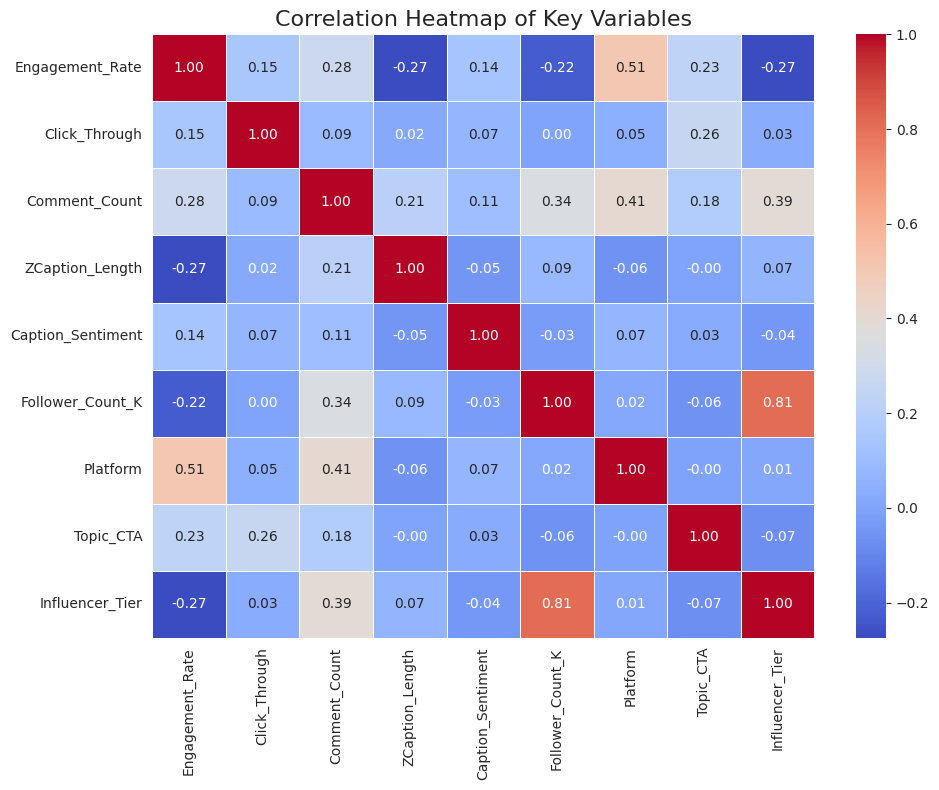

/tmp/ipykernel_12685/4119221738.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product_Category', y='Engagement_Rate', data=df, palette='cividis')


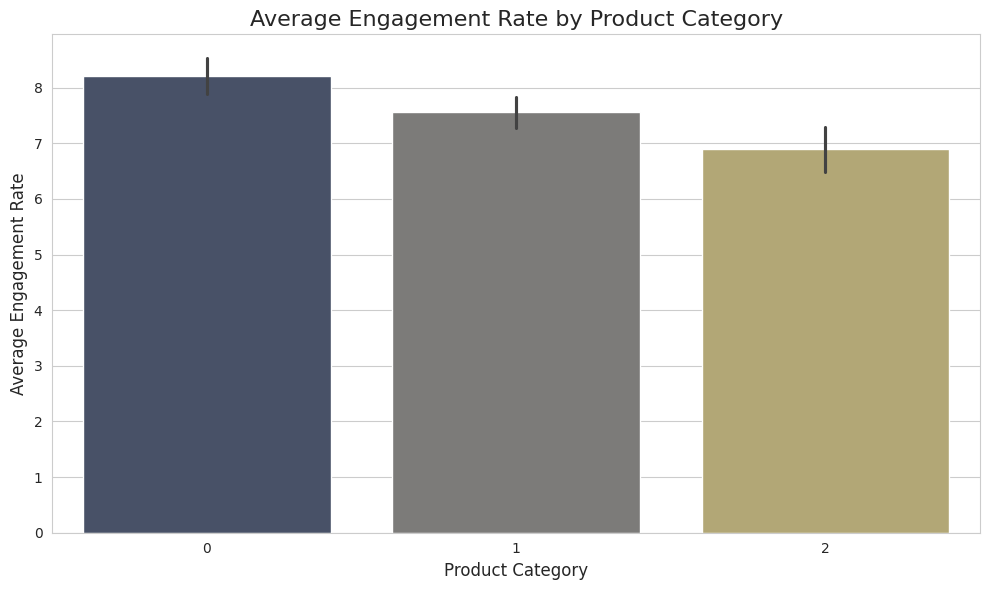

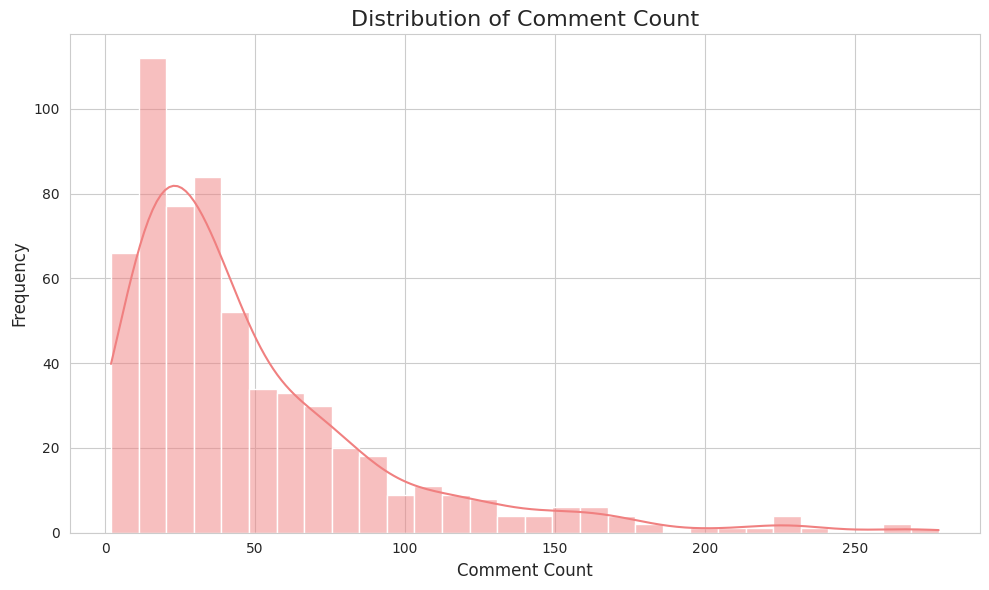

/tmp/ipykernel_12685/4119221738.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Influencer_Tier', y='Engagement_Rate', data=df, palette='pastel')


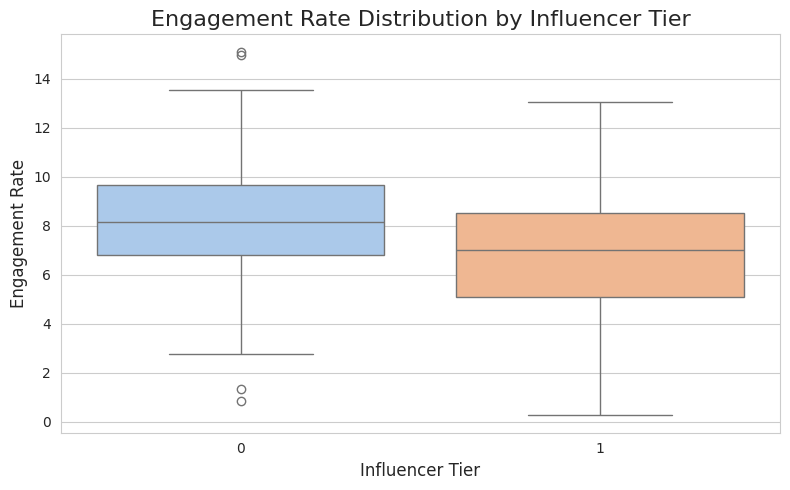

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (needed for df to be defined in this cell's context)
file_path = '/content/Team Assignment 1 Data 2026.xlsx'
df = pd.read_excel(file_path)

# Create dummies for Product_Category (as done in VzQfY0Z9eeOj)
prod_dummies = pd.get_dummies(df['Product_Category'], prefix='ProdCat', drop_first=True).astype(int)
df = pd.concat([df, prod_dummies], axis=1)

# Set style for plots for better aesthetics
sns.set_style("whitegrid")

print("Generating charts for data exploration...")

# --- Chart 1: Distribution of Engagement_Rate ---
plt.figure(figsize=(10, 6))
sns.histplot(df['Engagement_Rate'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Engagement Rate', fontsize=16)
plt.xlabel('Engagement Rate', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

# --- Chart 2: Scatter plot of Engagement_Rate vs. ZCaption_Length ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ZCaption_Length', y='Engagement_Rate', data=df, hue='Platform', palette='viridis', alpha=0.7)
plt.title('Engagement Rate vs. Z-scored Caption Length by Platform', fontsize=16)
plt.xlabel('Z-scored Caption Length', fontsize=12)
plt.ylabel('Engagement Rate', fontsize=12)
plt.legend(title='Platform')
plt.tight_layout()
plt.show()

# --- Chart 3: Bar plot of Average Engagement_Rate by Platform ---
plt.figure(figsize=(8, 5))
sns.barplot(x='Platform', y='Engagement_Rate', data=df, palette='magma')
plt.title('Average Engagement Rate by Platform', fontsize=16)
plt.xlabel('Platform (0 or 1)', fontsize=12)
plt.ylabel('Average Engagement Rate', fontsize=12)
plt.tight_layout()
plt.show()

# --- Chart 4: Correlation Heatmap for selected variables ---
plt.figure(figsize=(10, 8))
corr_vars = ['Engagement_Rate', 'Click_Through', 'Comment_Count', 'ZCaption_Length', 'Caption_Sentiment', 'Follower_Count_K', 'Platform', 'Topic_CTA', 'Influencer_Tier']
correlation_matrix = df[corr_vars].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Key Variables', fontsize=16)
plt.tight_layout()
plt.show()

# --- Chart 5: Bar plot of Average Engagement_Rate by Product_Category ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Product_Category', y='Engagement_Rate', data=df, palette='cividis')
plt.title('Average Engagement Rate by Product Category', fontsize=16)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Average Engagement Rate', fontsize=12)
plt.tight_layout()
plt.show()

# --- Chart 6: Distribution of Comment_Count ---
plt.figure(figsize=(10, 6))
sns.histplot(df['Comment_Count'], kde=True, bins=30, color='lightcoral')
plt.title('Distribution of Comment Count', fontsize=16)
plt.xlabel('Comment Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

# --- Chart 7: Box plot of Engagement_Rate by Influencer_Tier ---
plt.figure(figsize=(8, 5))
sns.boxplot(x='Influencer_Tier', y='Engagement_Rate', data=df, palette='pastel')
plt.title('Engagement Rate Distribution by Influencer Tier', fontsize=16)
plt.xlabel('Influencer Tier', fontsize=12)
plt.ylabel('Engagement Rate', fontsize=12)
plt.tight_layout()
plt.show()